#### Task:

1. Regression analysis over data to find correlation coefficients.
2. Pirson test over data to prove linear coleniariy over data
3. If Pirson test failed then chek Spearman test which is less depends on high VAR.

# Import libs

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

In [2]:
path = "../AdvancedModels/for CER.xlsx"

In [108]:
pip freeze

altair==5.5.0
asttokens==3.0.0
attrs==25.1.0
blinker==1.9.0
cachetools==5.5.2
certifi==2025.1.31
charset-normalizer==3.4.1
click==8.1.8
comm==0.2.2
contourpy==1.3.1
cycler==0.12.1
-e git+https://github.com/GishB/DirectionalDrillingChangePointDetection.git@3d4b837c0d1c21a6bb0854198a28cf336fdf8532#egg=dd_cpd
debugpy==1.8.13
decorator==5.2.1
detecta==0.0.5
drilling-change-point-detection @ file:///home/gishb/PycharmProjects/DirectionalDrillingChangePointDetection
et_xmlfile==2.0.0
exceptiongroup==1.2.2
executing==2.2.0
filelock==3.18.0
fonttools==4.56.0
fsspec==2025.3.2
gitdb==4.0.12
GitPython==3.1.44
idna==3.10
importlib_metadata==7.2.1
iniconfig==2.0.0
ipykernel==6.29.5
ipython==8.34.0
jedi==0.19.2
Jinja2==3.1.6
joblib==1.4.2
jsonschema==4.23.0
jsonschema-specifications==2024.10.1
jupyter_client==8.6.3
jupyter_core==5.7.2
kiwisolver==1.4.8
markdown-it-py==3.0.0
MarkupSafe==3.0.2
matplotlib==3.7.5
matplotlib-inline==0.1.7
mdurl==0.1.2
mpmath==1.3.0
narwhals==1.30.0
nest-asyncio==1.6.0
ne

# Read data

In [104]:
df = pd.read_excel(path)

In [105]:
df.drop(axis=0, columns=["закр", "year"], inplace=True)

# General Analysis

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   ROA       72 non-null     float64
 1   ROE       72 non-null     float64
 2   AI_Score  72 non-null     float64
 3   R&D       72 non-null     int64  
 4   F_SIZ     72 non-null     float64
 5   LEV       72 non-null     float64
 6   F_AGE     72 non-null     float64
dtypes: float64(6), int64(1)
memory usage: 4.1 KB


In [8]:
def heatmap(data, row_labels, col_labels, ax=None,
            cbar_kw=None, cbarlabel="", **kwargs):
    """
    Create a heatmap from a numpy array and two lists of labels.

    Parameters
    ----------
    data
        A 2D numpy array of shape (M, N).
    row_labels
        A list or array of length M with the labels for the rows.
    col_labels
        A list or array of length N with the labels for the columns.
    ax
        A `matplotlib.axes.Axes` instance to which the heatmap is plotted.  If
        not provided, use current Axes or create a new one.  Optional.
    cbar_kw
        A dictionary with arguments to `matplotlib.Figure.colorbar`.  Optional.
    cbarlabel
        The label for the colorbar.  Optional.
    **kwargs
        All other arguments are forwarded to `imshow`.
    """

    if ax is None:
        ax = plt.gca()

    if cbar_kw is None:
        cbar_kw = {}

    # Plot the heatmap
    im = ax.imshow(data, **kwargs)

    # Create colorbar
    cbar = ax.figure.colorbar(im, ax=ax, **cbar_kw)
    cbar.ax.set_ylabel(cbarlabel, rotation=-90, va="bottom")

    # Show all ticks and label them with the respective list entries.
    ax.set_xticks(range(data.shape[1]), labels=col_labels,
                  rotation=-30, ha="right", rotation_mode="anchor")
    ax.set_yticks(range(data.shape[0]), labels=row_labels)

    # Let the horizontal axes labeling appear on top.
    ax.tick_params(top=True, bottom=False,
                   labeltop=True, labelbottom=False)

    # Turn spines off and create white grid.
    ax.spines[:].set_visible(False)

    ax.set_xticks(np.arange(data.shape[1]+1)-.5, minor=True)
    ax.set_yticks(np.arange(data.shape[0]+1)-.5, minor=True)
    ax.grid(which="minor", color="w", linestyle='-', linewidth=3)
    ax.tick_params(which="minor", bottom=False, left=False)

    return im, cbar


def annotate_heatmap(im, data=None, valfmt="{x:.2f}",
                     textcolors=("black", "white"),
                     threshold=None, **textkw):
    """
    A function to annotate a heatmap.

    Parameters
    ----------
    im
        The AxesImage to be labeled.
    data
        Data used to annotate.  If None, the image's data is used.  Optional.
    valfmt
        The format of the annotations inside the heatmap.  This should either
        use the string format method, e.g. "$ {x:.2f}", or be a
        `matplotlib.ticker.Formatter`.  Optional.
    textcolors
        A pair of colors.  The first is used for values below a threshold,
        the second for those above.  Optional.
    threshold
        Value in data units according to which the colors from textcolors are
        applied.  If None (the default) uses the middle of the colormap as
        separation.  Optional.
    **kwargs
        All other arguments are forwarded to each call to `text` used to create
        the text labels.
    """

    if not isinstance(data, (list, np.ndarray)):
        data = im.get_array()

    # Normalize the threshold to the images color range.
    if threshold is not None:
        threshold = im.norm(threshold)
    else:
        threshold = im.norm(data.max())/2.

    # Set default alignment to center, but allow it to be
    # overwritten by textkw.
    kw = dict(horizontalalignment="center",
              verticalalignment="center")
    kw.update(textkw)

    # Get the formatter in case a string is supplied
    if isinstance(valfmt, str):
        valfmt = matplotlib.ticker.StrMethodFormatter(valfmt)

    # Loop over the data and create a `Text` for each "pixel".
    # Change the text's color depending on the data.
    texts = []
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            kw.update(color=textcolors[int(im.norm(data[i, j]) > threshold)])
            text = im.axes.text(j, i, valfmt(data[i, j], None), **kw)
            texts.append(text)

    return texts

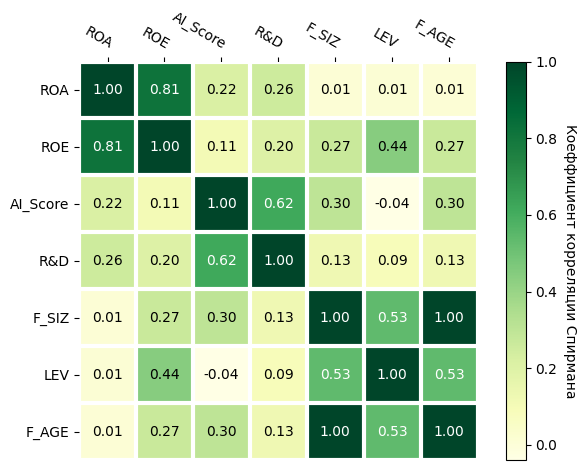

In [31]:
fig, ax = plt.subplots()

im, cbar = heatmap(df.corr(method="spearman").to_numpy(), df.corr().columns.to_list(), list(df.corr()), ax=ax,
                   cmap="YlGn", cbarlabel="Коеффициент корреляции Спирмана")
texts = annotate_heatmap(im, valfmt="{x:.2f}")

fig.tight_layout()
plt.show()

In [60]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [55]:
y = df["AI_Score"]
X = df.drop(axis=0, columns=["AI_Score"])

In [56]:
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [74]:
pd.DataFrame(list(model.coef_), index=[X.columns], columns=["AI_Score"]).sort_values(by="AI_Score")

,AI_Score
F_AGE,-9.739088e-03
ROA,-1.235076e-03
LEV,-7.401141e-04
R&D,1.140460e-13
ROE,8.496547e-04
F_SIZ,3.863983e-02


In [75]:
# Predict
ypred = model.predict(X)

# Calculate scores
r2 = r2_score(y, ypred)
mse = mean_squared_error(y, ypred)

print(f"R² Score: {r2:.4f}")
print(f"MSE: {mse:.4f}")
pd.DataFrame(list(model.coef_), index=[X.columns], columns=["AI_Score"]).sort_values(by="AI_Score")

R² Score: 0.5862
MSE: 0.0000


,AI_Score
F_AGE,-9.739088e-03
ROA,-1.235076e-03
LEV,-7.401141e-04
R&D,1.140460e-13
ROE,8.496547e-04
F_SIZ,3.863983e-02


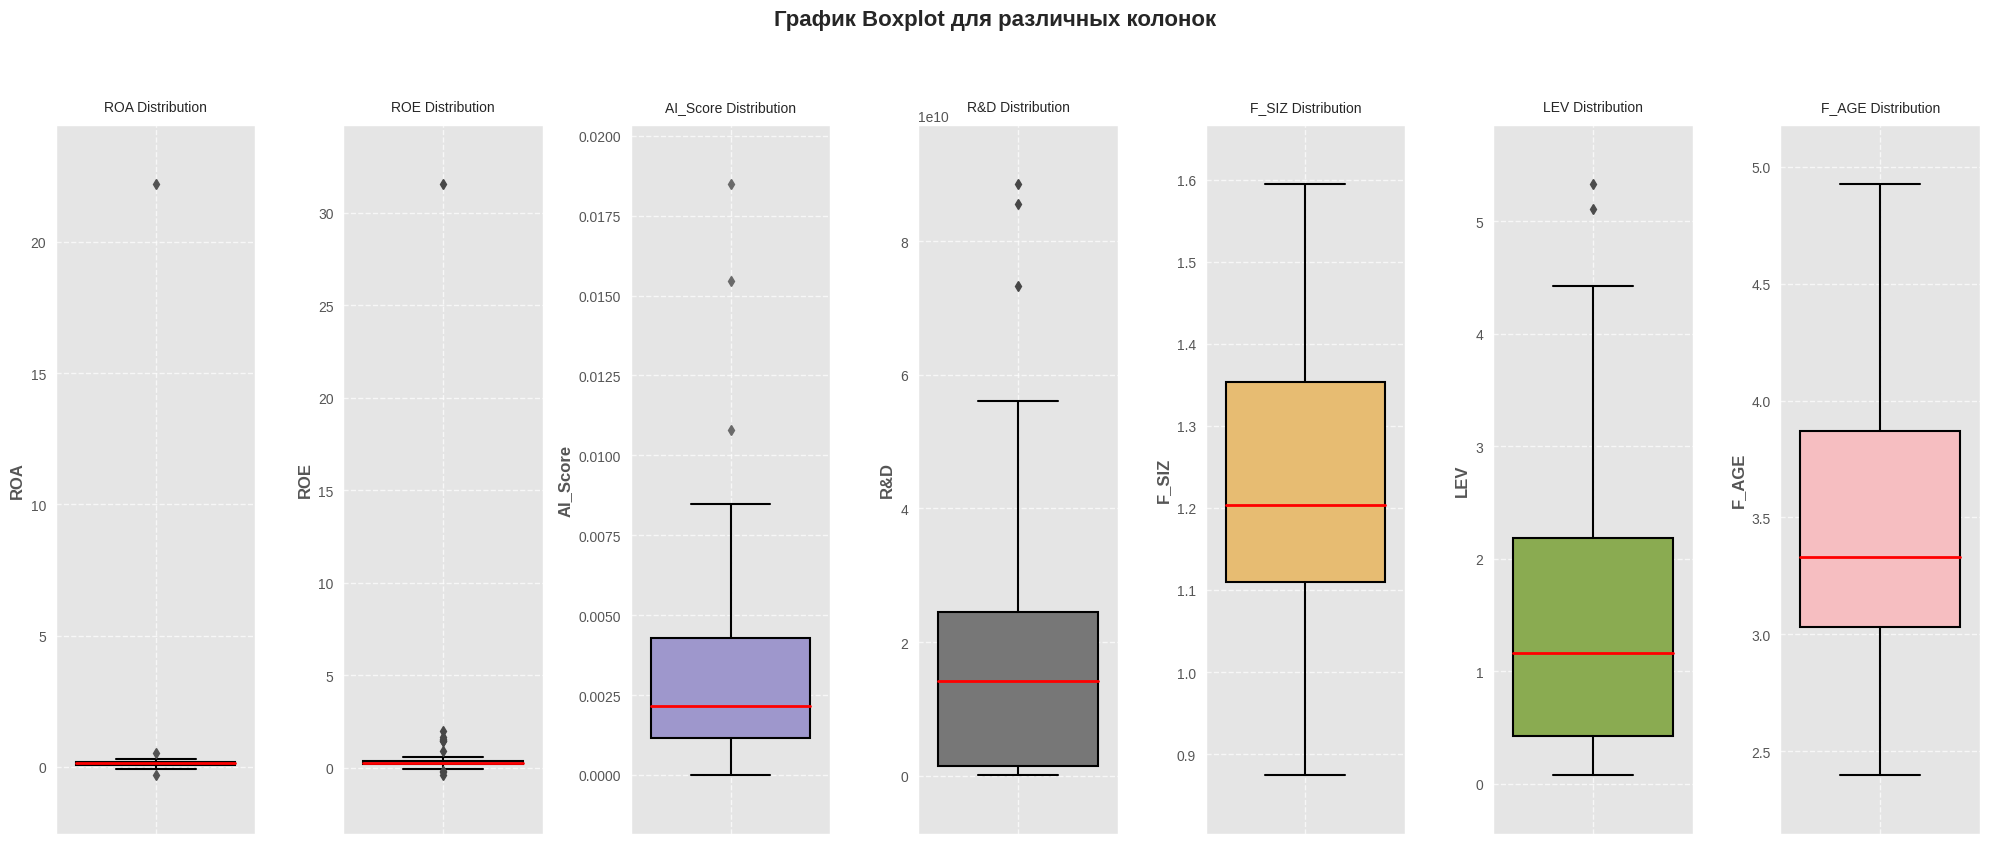

In [107]:
plt.style.use('ggplot')  # Updated Seaborn style

# Create subplots (1 row, one plot per column)
fig, axes = plt.subplots(1, len(df.columns), figsize=(20, 8), dpi=100)

# Add a super title
fig.suptitle('График Boxplot для различных колонок', fontsize=16, weight='bold', y=1.05)

# Customize each boxplot
for i, col in enumerate(df.columns):
    ax = axes[i] if len(df.columns) > 1 else axes  # Handle single-column case
    sns.boxplot(y=df[col], ax=ax, 
                color=f'C{i}',  # Unique color per boxplot
                boxprops=dict(edgecolor='black', linewidth=1.5),
                whiskerprops=dict(color='black', linewidth=1.5),
                capprops=dict(color='black', linewidth=1.5),
                medianprops=dict(color='red', linewidth=2))  # Highlight median
    
    # Set y-limits dynamically with padding
    col_min, col_max = df[col].min(), df[col].max()
    padding = (col_max - col_min) * 0.1  # 10% padding
    ax.set_ylim(col_min - padding, col_max + padding)
    
    # Labels and styling
    ax.set_ylabel(col, fontsize=12, weight='bold')
    ax.set_title(f'{col} Distribution', fontsize=10, pad=10)
    ax.grid(True, linestyle='--', alpha=0.7)  # Subtle grid
    
    # Rotate x-axis labels if needed (for readability, though boxplot has no x-ticks here)
    ax.tick_params(axis='y', labelsize=10)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()